In [1]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
# load dataset
url = 'https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/Mall_Customers.csv'
df = pd.read_csv(url)

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
#elect features
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [8]:
#Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

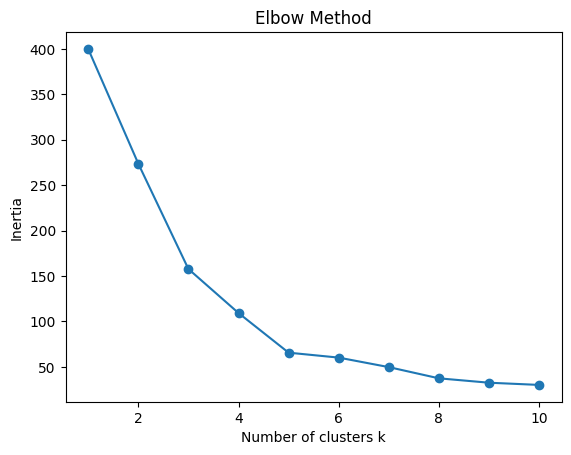

In [14]:
# find optimal K (Elbow + Silhoutte)
inertia = []
k_range = range(1,11)
for k in k_range:
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(X_scaled)
  inertia.append(km.inertia_)


plt.figure()
plt.plot(k_range, inertia, 'o-')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [16]:
# finding the optimal value of k
for k in range(2,7):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(X_scaled)
  score = silhouette_score(X_scaled, km.labels_)
  print(f'Silhoutte score for K:{score:.3f}')

Silhoutte score for K:0.397
Silhoutte score for K:0.467
Silhoutte score for K:0.494
Silhoutte score for K:0.555
Silhoutte score for K:0.514


In [17]:
#optimal value of k and then clustering
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

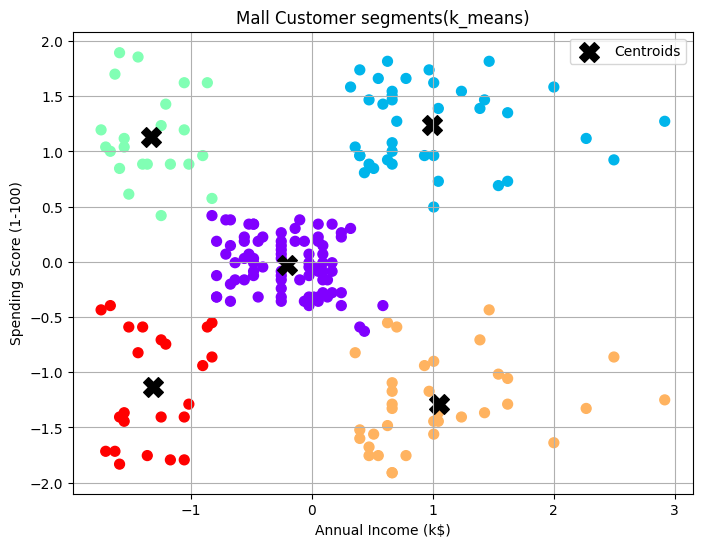

In [26]:
#visualize clusters
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=labels, cmap='rainbow', s=50)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='Black',marker='X', s= 200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Mall Customer segments(k_means)')
plt.legend()
plt.grid(True)
plt.show()